In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import math

In [2]:
my_seed = int(time.time())
rng = np.random.default_rng(seed=my_seed)
my_seed

1780610523

# KMeans algorithm

In [3]:
def _validate_inputs(k, X):
    if X is None or X.size == 0:
        raise ValueError("Error: Dataset X is empty.")
    if k <= 0:
        raise ValueError(f"Error: k must be greater than 0. Received k={k}.")
    if k > X.shape[0]:
        raise ValueError(f"Error: k ({k}) cannot be greater than the number of data points in the dataset ({X.shape[0]}).")
    if np.isnan(X).any() or np.isinf(X).any():
        raise ValueError("Error: Dataset X contains NaN (Not a Number) or Infinite values.")

In [4]:
def _inner_kmeans(k, X, centroids):
    while True:
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])
        if np.allclose(centroids, new_centroids): break
        centroids = new_centroids
    return centroids, distances, labels

In [5]:
def kmeans(k, X):
    _validate_inputs(k, X)
    return _inner_kmeans(k, X, 
        X[rng.choice(X.shape[0], size=k, replace=False)]
    )

# KMeans++ algorithm

In [6]:
def kmeans_plus_plus(k, X):
    _validate_inputs(k, X)
    centroids = [X[rng.choice(X.shape[0])]]
    D2 = np.inf 
    for _ in range(1, k):
        D2 = np.minimum(D2, np.sum((X - centroids[-1])**2, axis=1))
        sum_D2 = np.sum(D2)
        probs = D2 / sum_D2 if sum_D2 > 0 else np.ones(X.shape[0]) / X.shape[0]
        centroids.append(X[rng.choice(X.shape[0], p=probs)])
    return _inner_kmeans(k, X, np.array(centroids))

# Utility functions

In [7]:
def run_trials(algo, k, X, trials):
    times, inertias, bincounts = [], [], []
    for trial in range(trials):
        start = time.perf_counter()
        _, distances, labels = algo(k, X)
        end = time.perf_counter()
        times.append(end - start)
        inertias.append(np.sum(np.min(distances**2, axis=1)))
        bincounts.append(np.bincount(labels, minlength=k))
    return {'inertias': inertias, 'times': times, 'bincounts': bincounts}

In [8]:
def show_distributions(bincounts, filename):
    trials = len(bincounts)
    rows = math.floor(math.sqrt(trials))
    cols = math.ceil(trials / rows)
    _, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    for i in range(trials): show_bar_diagram(bincounts[i], axes[i], f"Trial {i + 1}")
    plt.tight_layout()
    plt.savefig(f'img/{filename}.jpg', dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
def show_bar_diagram(count, ax, title):
    ax.bar(range(len(count)), count, color='royalblue', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster ID', fontsize=10)
    ax.set_ylabel('Number of datapoints', fontsize=10)
    ax.set_xticks(range(len(count)))
    ax.set_xticklabels(range(len(count)), rotation=90, fontsize=5)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

In [10]:
def show_boxplot(ax, k, is_first, stats):
    box = ax.boxplot(
        [stats[k]['kmeans']['inertias'], stats[k]['kmeanspp']['inertias']], 
        tick_labels=['KMeans', 'KMeans++'],
        patch_artist=True,
        widths=0.5
    )
    for patch, color in zip(box['boxes'], ['#aec7e8', '#98df8a']):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
    for median in box['medians']: median.set(color='black', linewidth=1.5)
    ax.set_title(f'k = {k}', fontsize=14, fontweight='bold')
    if is_first: ax.set_ylabel('Inertia', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

In [11]:
def show_stability_graphs(stats, filename):
    number_of_k_values = len(stats.keys())
    rows = math.floor(math.sqrt(number_of_k_values))
    cols = math.ceil(number_of_k_values / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6), sharey=False)
    for i, k in enumerate(stats.keys()): show_boxplot(axes[i], k, i == 0, stats)
    fig.suptitle('Stability comparison: KMeans vs KMeans++', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f'img/{filename}.jpg', dpi=300, bbox_inches="tight")
    plt.show()

# Synthetic dataset

### Generation

To evaluate the algorithms in a controlled environment, we generated a synthetic dataset following the methodology described in Section 6.1 ("Datasets") of the foundational paper *"k-means++: The Advantages of Careful Seeding"* (Arthur & Vassilvitskii, SODA 2007). 

The dataset properties are configured as follows:
* **Dimensions:** $d = 20$
* **Centers:** $k = 27$, chosen uniformly at random from a 20-dimensional hypercube of side length $700$ centered at the origin.
* **Distribution:** For each center, $50$ data points were sampled from a multivariate Gaussian distribution with unit variance ($\sigma^2 = 1$).
* **Total Dataset Size:** $N = 1350$ data points ($27 \times 50$). 

> **Note:** The generating centers serve exclusively as the ground-truth distribution parameters and are not included as queryable points within the final dataset.

In [12]:
hypercube_center = 0 # in all dimensions
hypercube_side = 700
k = 27
d = 20
variance = 1
datapoints_per_center = 50

In [13]:
centers = rng.uniform(hypercube_center - hypercube_side/2, hypercube_center + hypercube_side/2, (k, d))
X = np.vstack([rng.normal(loc=c, scale=math.sqrt(variance), size=(datapoints_per_center, d)) for c in centers])
X

array([[  13.05701948, -281.34534134,   47.30953466, ...,  104.13779204,
        -207.1618337 ,  133.2084629 ],
       [  15.94323397, -281.3387585 ,   44.59202626, ...,  105.77456949,
        -206.75746041,  133.42609933],
       [  15.75946558, -281.89140071,   45.77046578, ...,  106.04428851,
        -206.53602219,  133.07432546],
       ...,
       [  68.16354488,  255.25510416, -229.21093799, ..., -326.60080072,
        -348.54918083, -224.06046331],
       [  67.60987794,  257.70512577, -227.45909992, ..., -327.00146494,
        -346.08701735, -223.88021379],
       [  71.33771337,  257.39274686, -226.41790825, ..., -326.31060372,
        -346.78143724, -224.47541791]], shape=(1350, 20))

In [14]:
centers.shape, X.shape

((27, 20), (1350, 20))

### Initialization

In [15]:
trials = 20

In [16]:
syn_k_values = [10, 27, 50]

In [17]:
syn_stats = {}
for k in syn_k_values: syn_stats[k] = {}

### KMeans executions

In [18]:
for k in syn_k_values:
    syn_stats[k]['kmeans'] = run_trials(kmeans, k, X, trials)

#### Stats

In [19]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(syn_stats[k]['kmeans']['times']):.4f} s")
    print(f"Average inertia: {np.mean(syn_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(syn_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(syn_stats[k]['kmeans']['inertias']):.4e}")
    if i < len(syn_k_values) - 1: print()

k = 10
--------------------
Average execution time: 0.0061 s
Average inertia: 5.9849e+08
Inertia standard deviation: 4.8286e+07
Minimum inertia: 5.3631e+08

k = 27
--------------------
Average execution time: 0.0192 s
Average inertia: 1.9129e+08
Inertia standard deviation: 4.6869e+07
Minimum inertia: 9.8752e+07

k = 50
--------------------
Average execution time: 0.0594 s
Average inertia: 5.2427e+07
Inertia standard deviation: 3.1767e+07
Minimum inertia: 2.4999e+04


#### Cluster sizes distributions

k = 10
--------------------


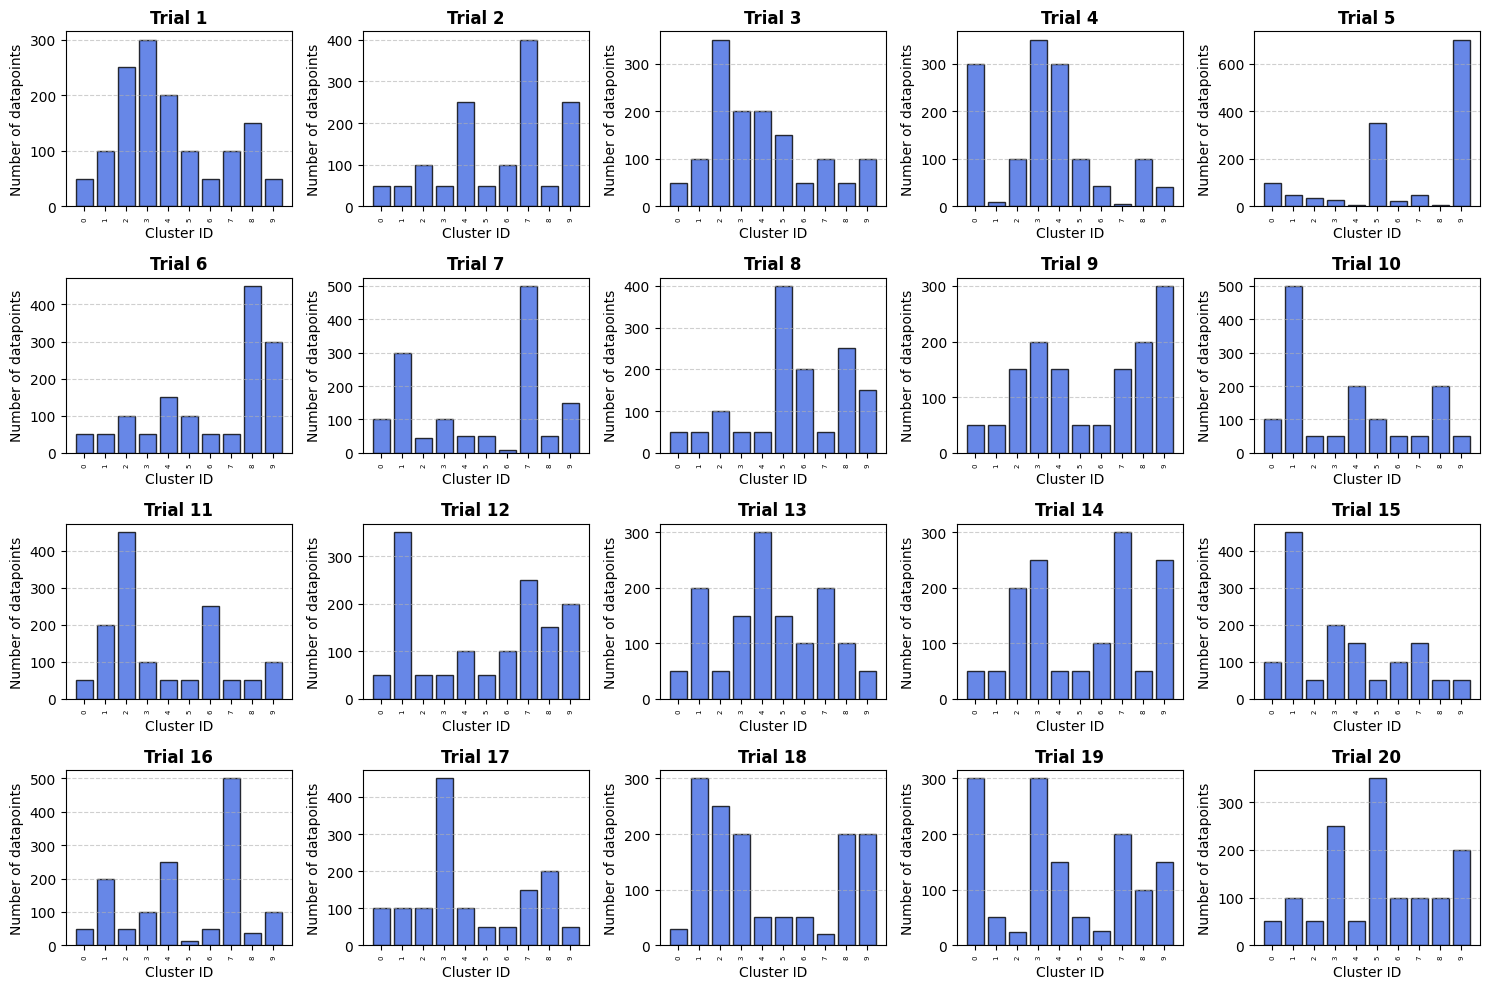


k = 27
--------------------


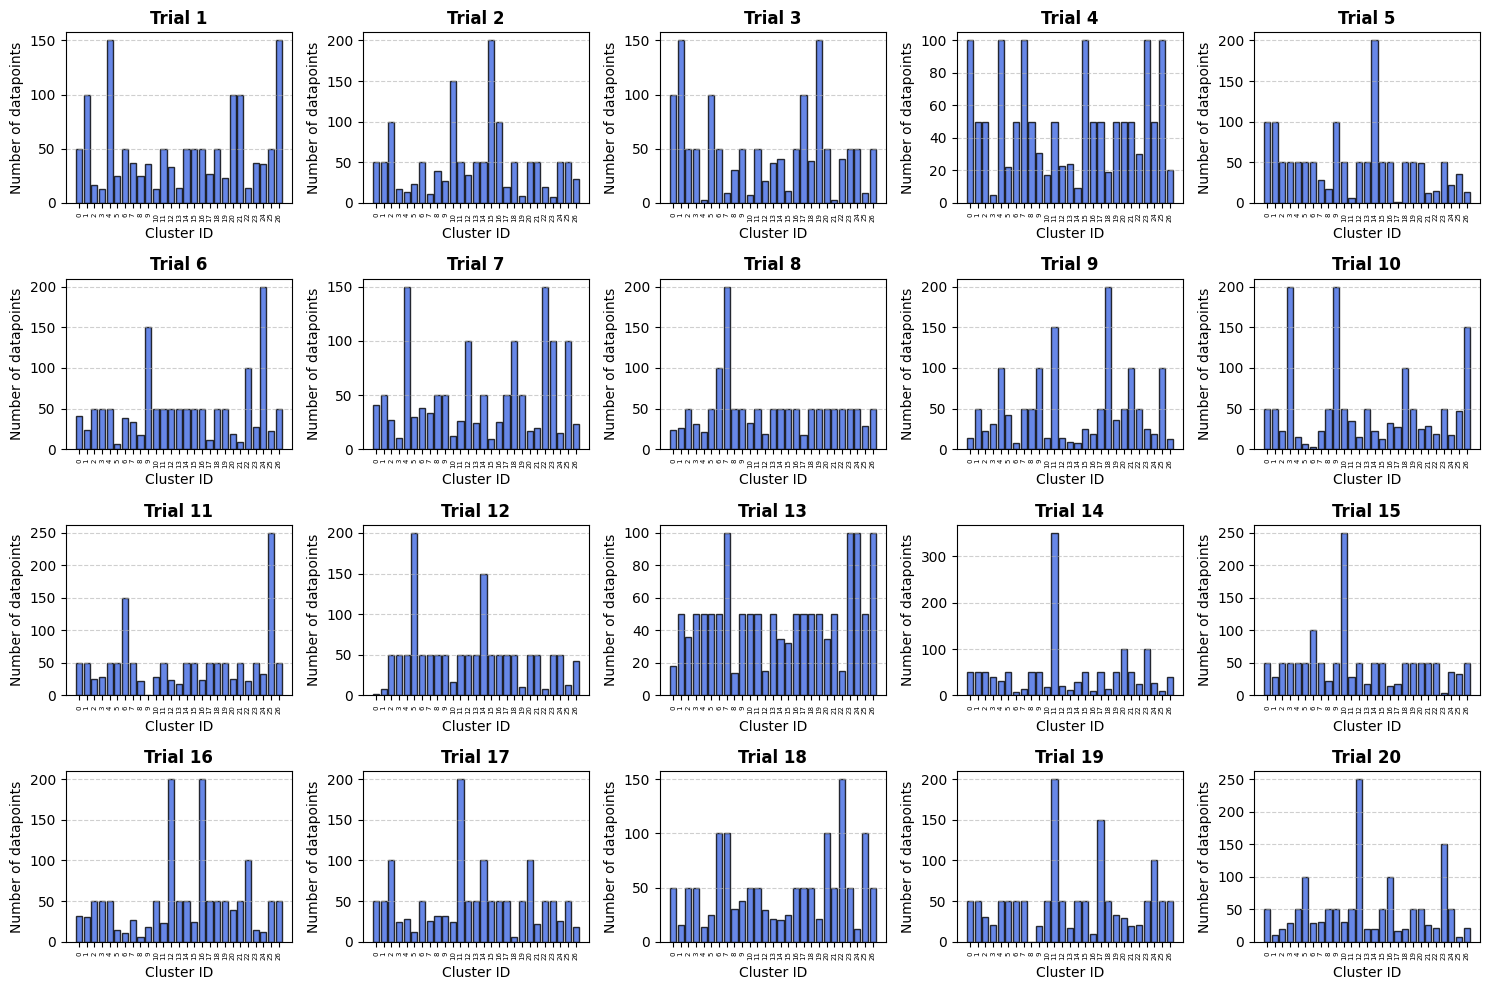


k = 50
--------------------


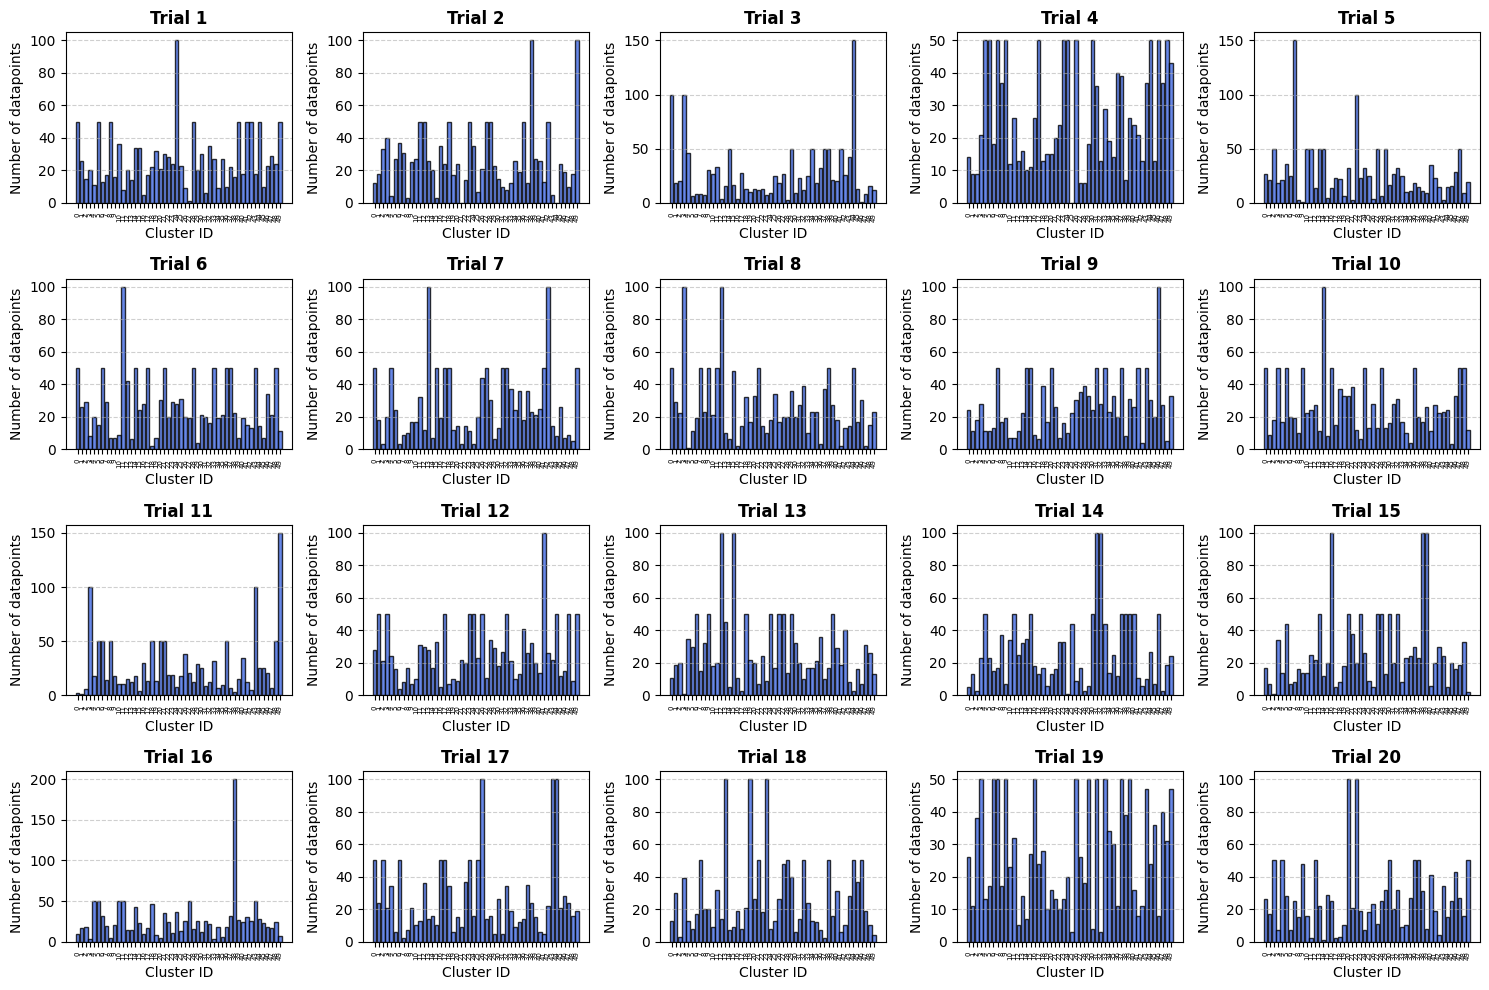

In [20]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(syn_stats[k]['kmeans']['bincounts'], f'cl_sz_distr_syn_km_k{k}')
    if i < len(syn_k_values) - 1: print()

### KMeans++ executions

In [21]:
for k in syn_k_values:
    syn_stats[k]['kmeanspp'] = run_trials(kmeans_plus_plus, k, X, trials)

#### Stats

In [22]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(syn_stats[k]['kmeanspp']['times']):.4f} s")
    print(f"Average inertia: {np.mean(syn_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(syn_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(syn_stats[k]['kmeanspp']['inertias']):.4e}")
    if i < len(syn_k_values) - 1: print()

k = 10
--------------------
Average execution time: 0.0045 s
Average inertia: 5.4851e+08
Inertia standard deviation: 1.9428e+07
Minimum inertia: 5.0588e+08

k = 27
--------------------
Average execution time: 0.0091 s
Average inertia: 2.6475e+04
Inertia standard deviation: 3.6380e-12
Minimum inertia: 2.6475e+04

k = 50
--------------------
Average execution time: 0.0524 s
Average inertia: 2.4988e+04
Inertia standard deviation: 7.1202e+01
Minimum inertia: 2.4836e+04


#### Cluster sizes distributions

k = 10
--------------------


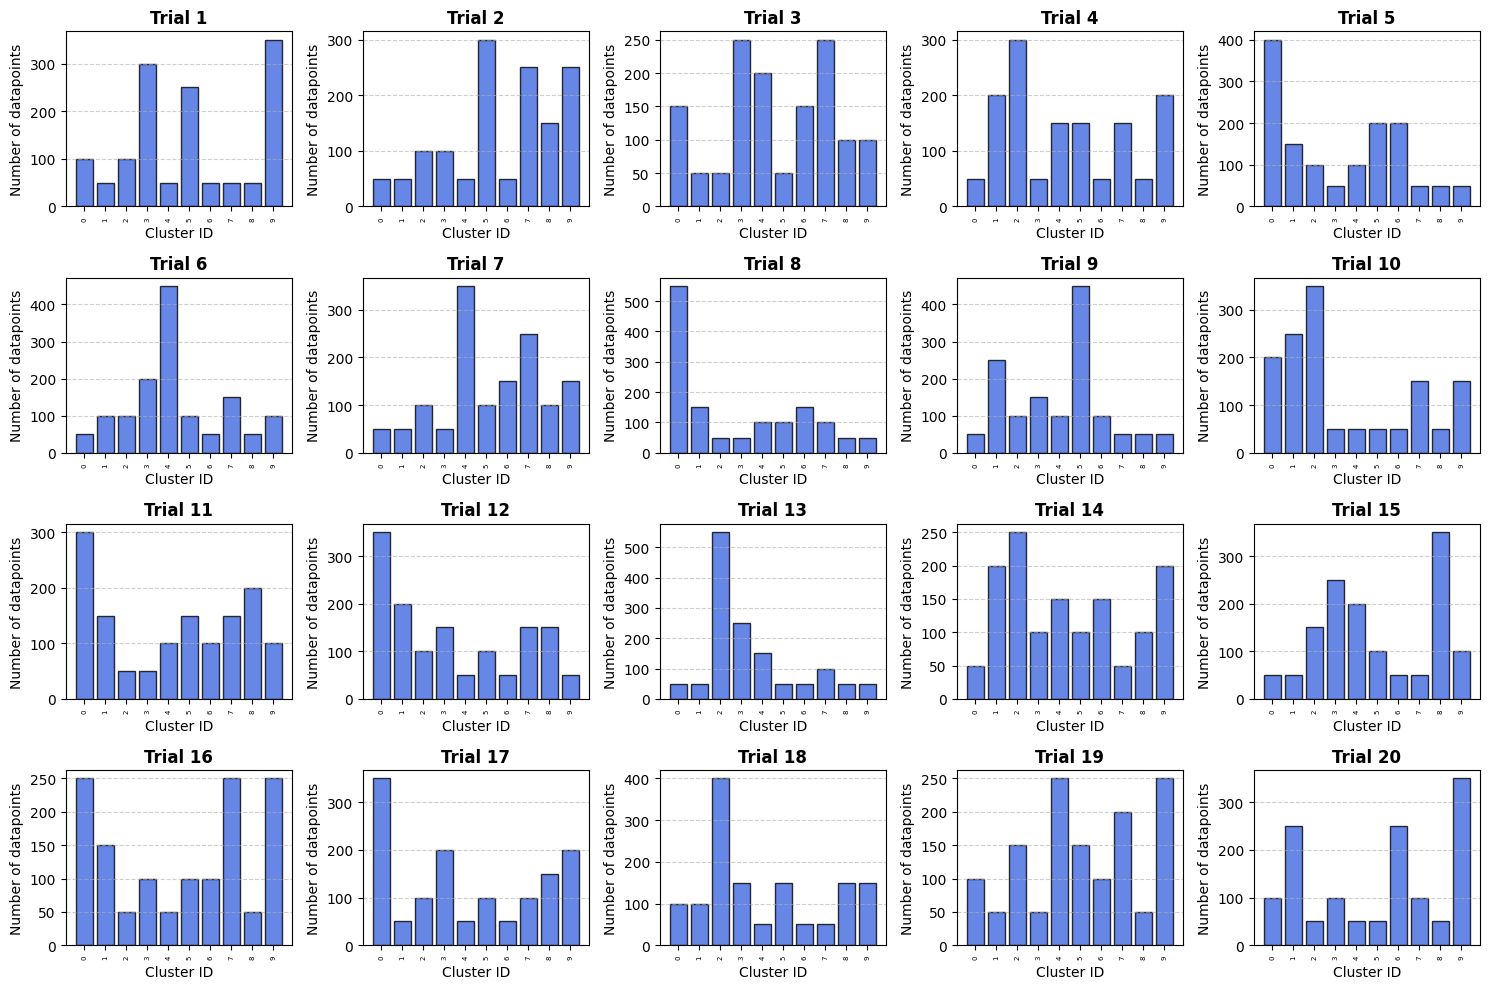


k = 27
--------------------


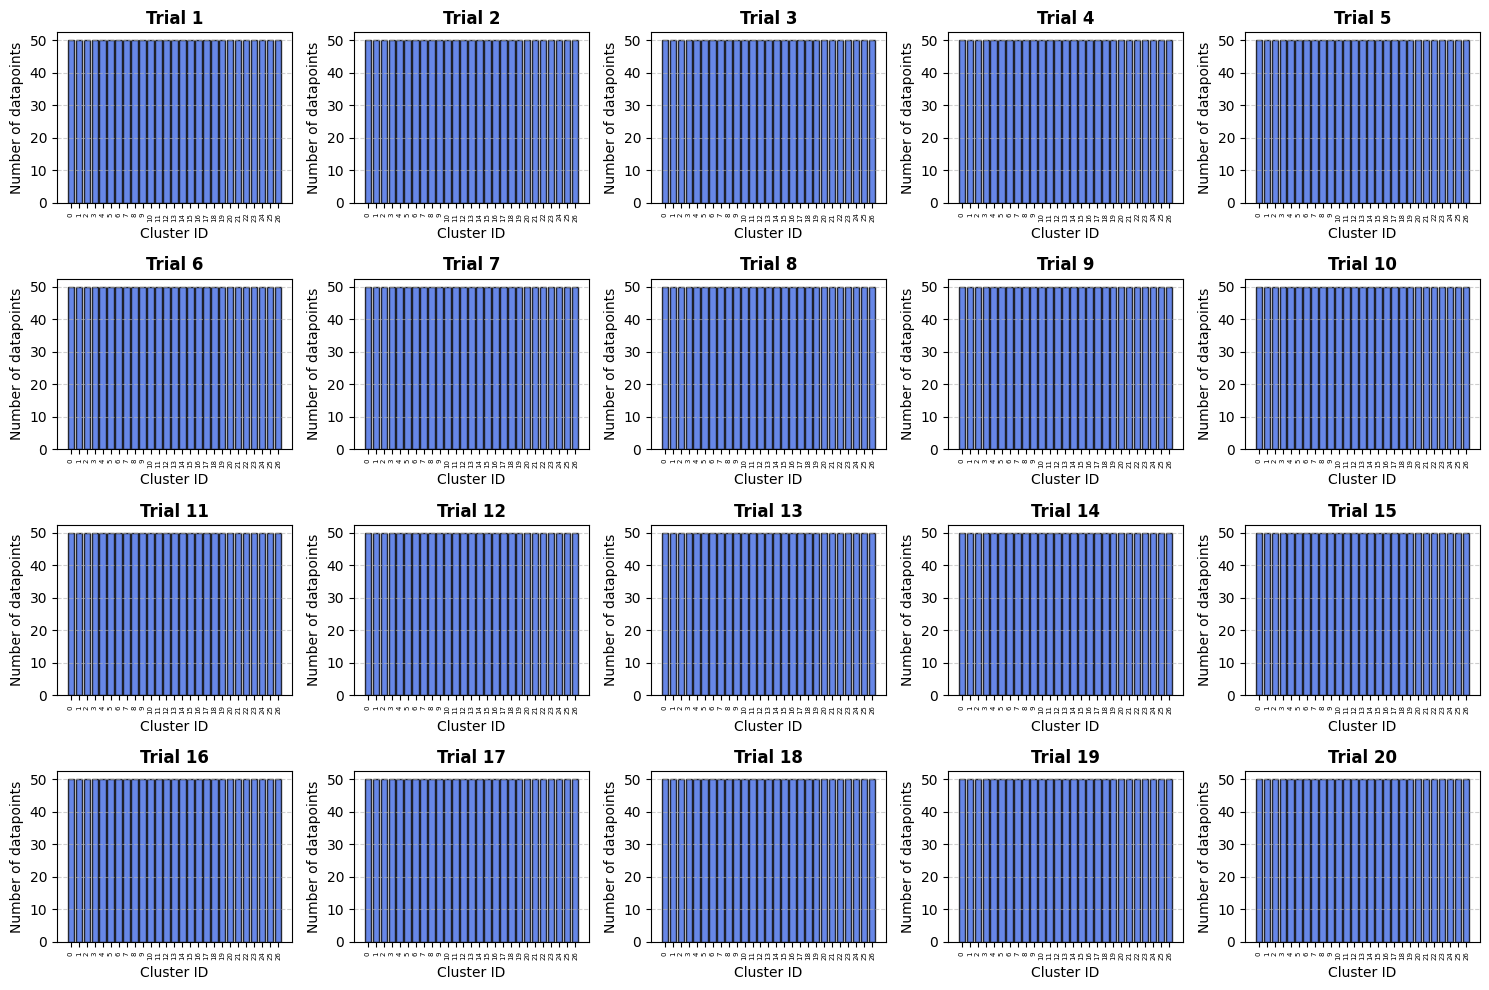


k = 50
--------------------


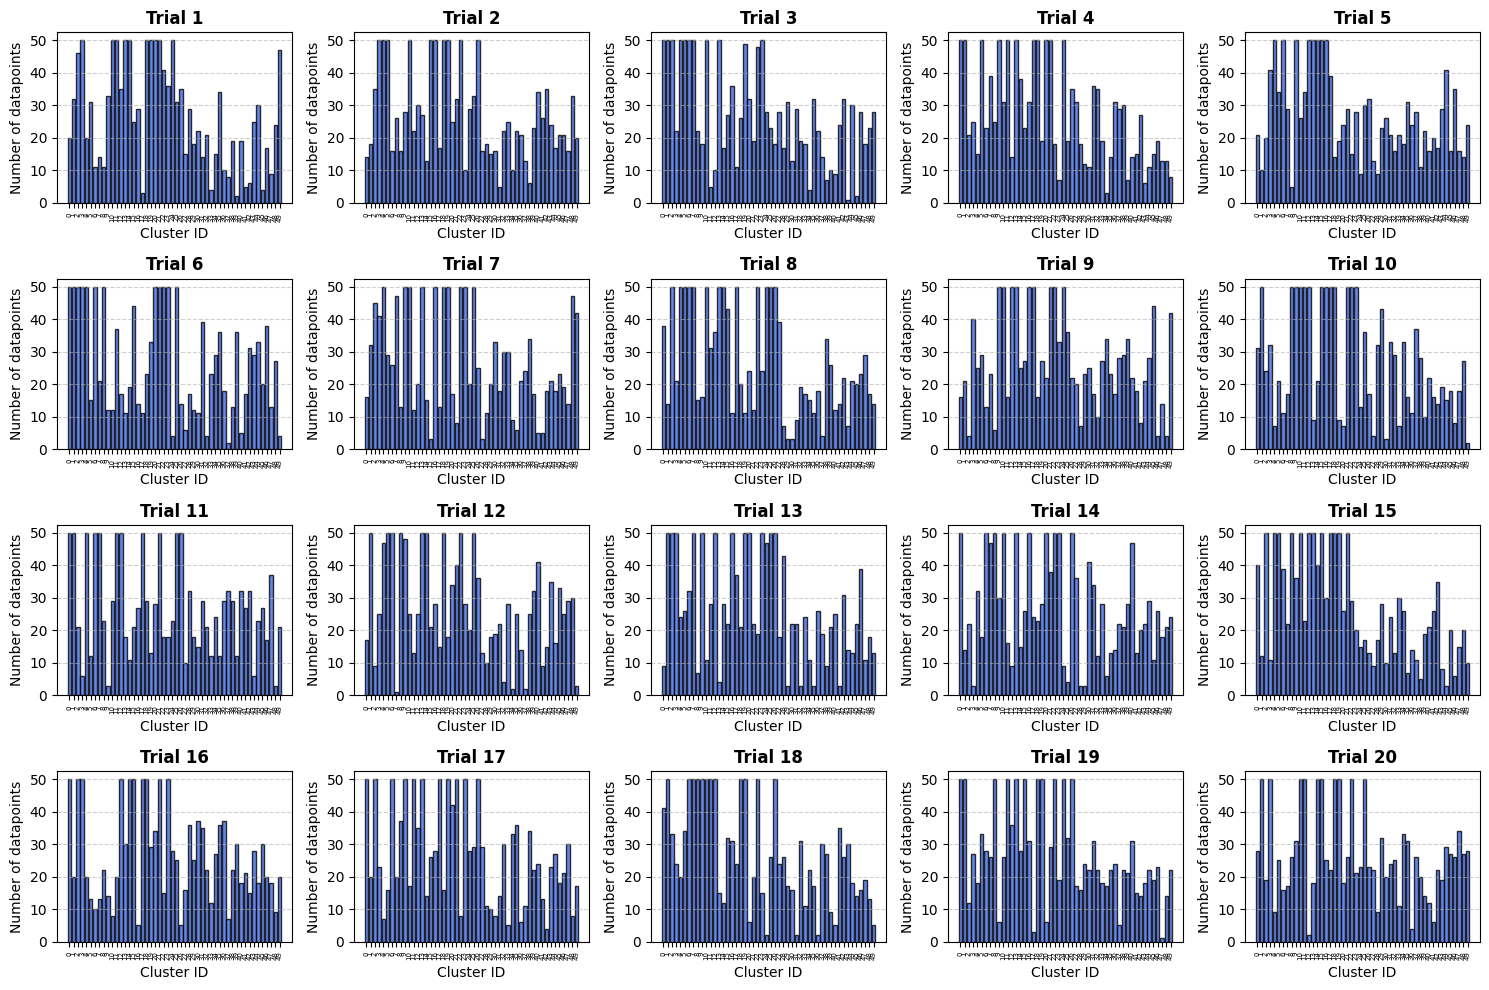

In [23]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(syn_stats[k]['kmeanspp']['bincounts'], f'cl_sz_distr_syn_kmpp_k{k}')
    if i < len(syn_k_values) - 1: print()

### Improvement analysis

In [24]:
for i, (k, v) in enumerate(syn_stats.items()):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time improvement: {100*(1-np.mean(syn_stats[k]['kmeanspp']['times']) / np.mean(syn_stats[k]['kmeans']['times']))}%")
    print(f"Average inertia improvement: {100*(1-np.mean(syn_stats[k]['kmeanspp']['inertias']) / np.mean(syn_stats[k]['kmeans']['inertias']))}%")
    print(f"Inertia standard deviation improvement: {100*(1-np.std(syn_stats[k]['kmeanspp']['inertias']) / np.std(syn_stats[k]['kmeans']['inertias']))}%")
    print(f"Minimum inertia improvement: {100*(1-np.min(syn_stats[k]['kmeanspp']['inertias']) / np.min(syn_stats[k]['kmeans']['inertias']))}%")
    if i < len(syn_stats.items()) - 1: print()

k = 10
--------------------
Average execution time improvement: 26.759104013226708%
Average inertia improvement: 8.349699124265154%
Inertia standard deviation improvement: 59.76438657554994%
Minimum inertia improvement: 5.673775671928761%

k = 27
--------------------
Average execution time improvement: 52.820049923853475%
Average inertia improvement: 99.98615965978723%
Inertia standard deviation improvement: 100.0%
Minimum inertia improvement: 99.97319013147364%

k = 50
--------------------
Average execution time improvement: 11.70928292684591%
Average inertia improvement: 99.95233632965702%
Inertia standard deviation improvement: 99.99977586374496%
Minimum inertia improvement: 0.6523166241335754%


### Stability analysis

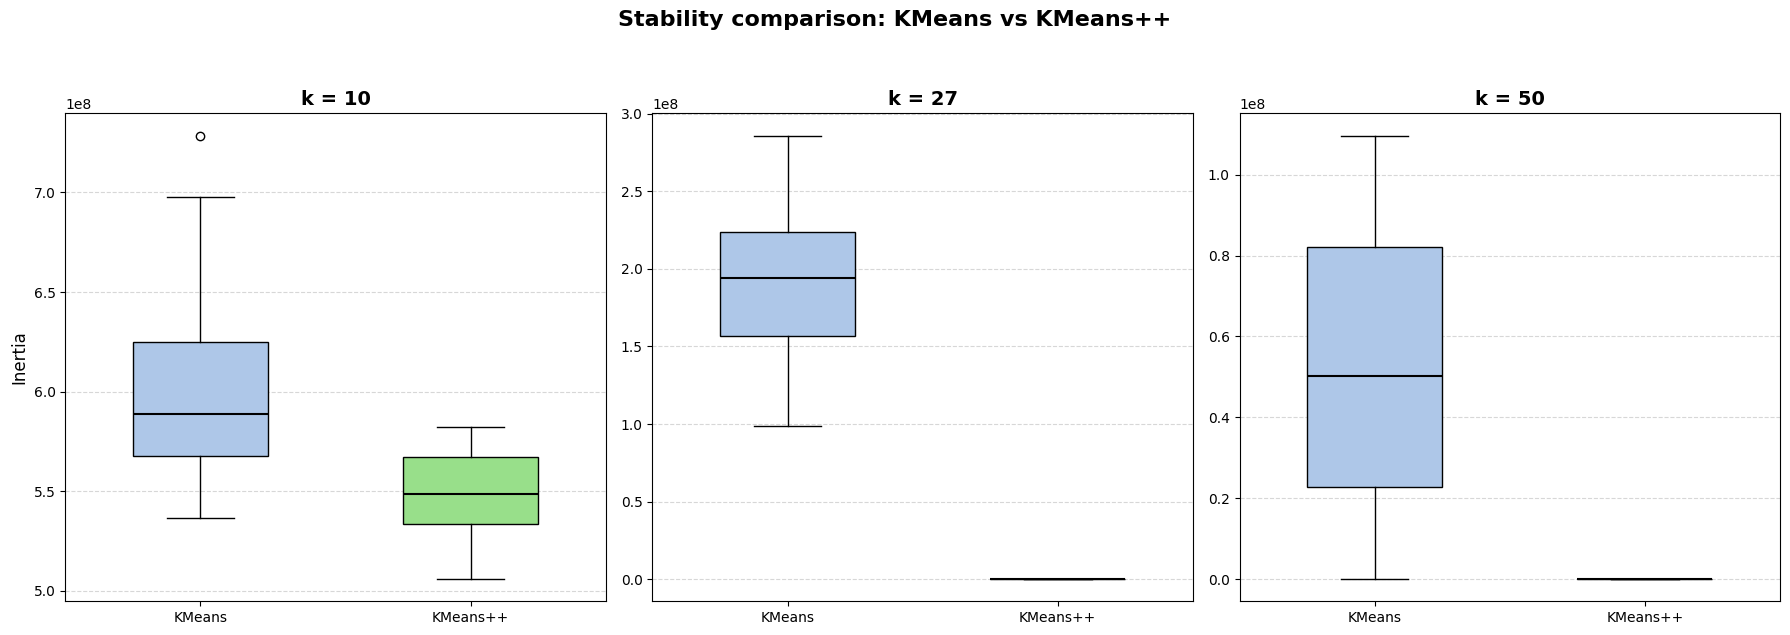

In [25]:
show_stability_graphs(syn_stats, 'stab_syn')

# Real dataset

### Parsing

In [26]:
data_real = np.loadtxt('isolet/isolet.data', delimiter=',')
X_real = data_real[:, :-1]
X_real

array([[-0.4394, -0.093 ,  0.1718, ...,  0.641 ,  0.5898, -0.4872],
       [-0.4348, -0.1198,  0.2474, ...,  0.4318,  0.4546, -0.091 ],
       [-0.233 ,  0.2124,  0.5014, ...,  0.254 ,  0.1588, -0.4762],
       ...,
       [-0.6696, -0.373 ,  0.1584, ...,  0.0728,  0.0728, -0.5818],
       [-0.5764, -0.1764,  0.5106, ...,  0.3044, -0.0434, -0.5   ],
       [-0.6624, -0.3334,  0.3666, ..., -0.0894, -0.1708, -0.317 ]],
      shape=(7797, 617))

### Normalization

In [27]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std[std == 0] = 1e-8
    return (X - mean) / std

In [28]:
X_real = standardize(X_real)

### Initialization

In [29]:
real_k_values = [10, 26, 50]

In [30]:
real_stats = {}
for k in real_k_values: real_stats[k] = {}

### KMeans executions

In [31]:
for k in real_k_values:
    real_stats[k]['kmeans'] = run_trials(kmeans, k, X_real, trials)

#### Stats

In [32]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(real_stats[k]['kmeans']['times']):.4f} s")
    print(f"Average inertia: {np.mean(real_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(real_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(real_stats[k]['kmeans']['inertias']):.4e}")
    if i < len(real_k_values) - 1: print()

k = 10
--------------------
Average execution time: 4.3109 s
Average inertia: 3.1530e+06
Inertia standard deviation: 1.2063e+04
Minimum inertia: 3.1353e+06

k = 26
--------------------
Average execution time: 13.0302 s
Average inertia: 2.6853e+06
Inertia standard deviation: 2.4727e+04
Minimum inertia: 2.6417e+06

k = 50
--------------------
Average execution time: 22.3064 s
Average inertia: 2.4472e+06
Inertia standard deviation: 9.0902e+03
Minimum inertia: 2.4305e+06


#### Cluster sizes distributions

k = 10
--------------------


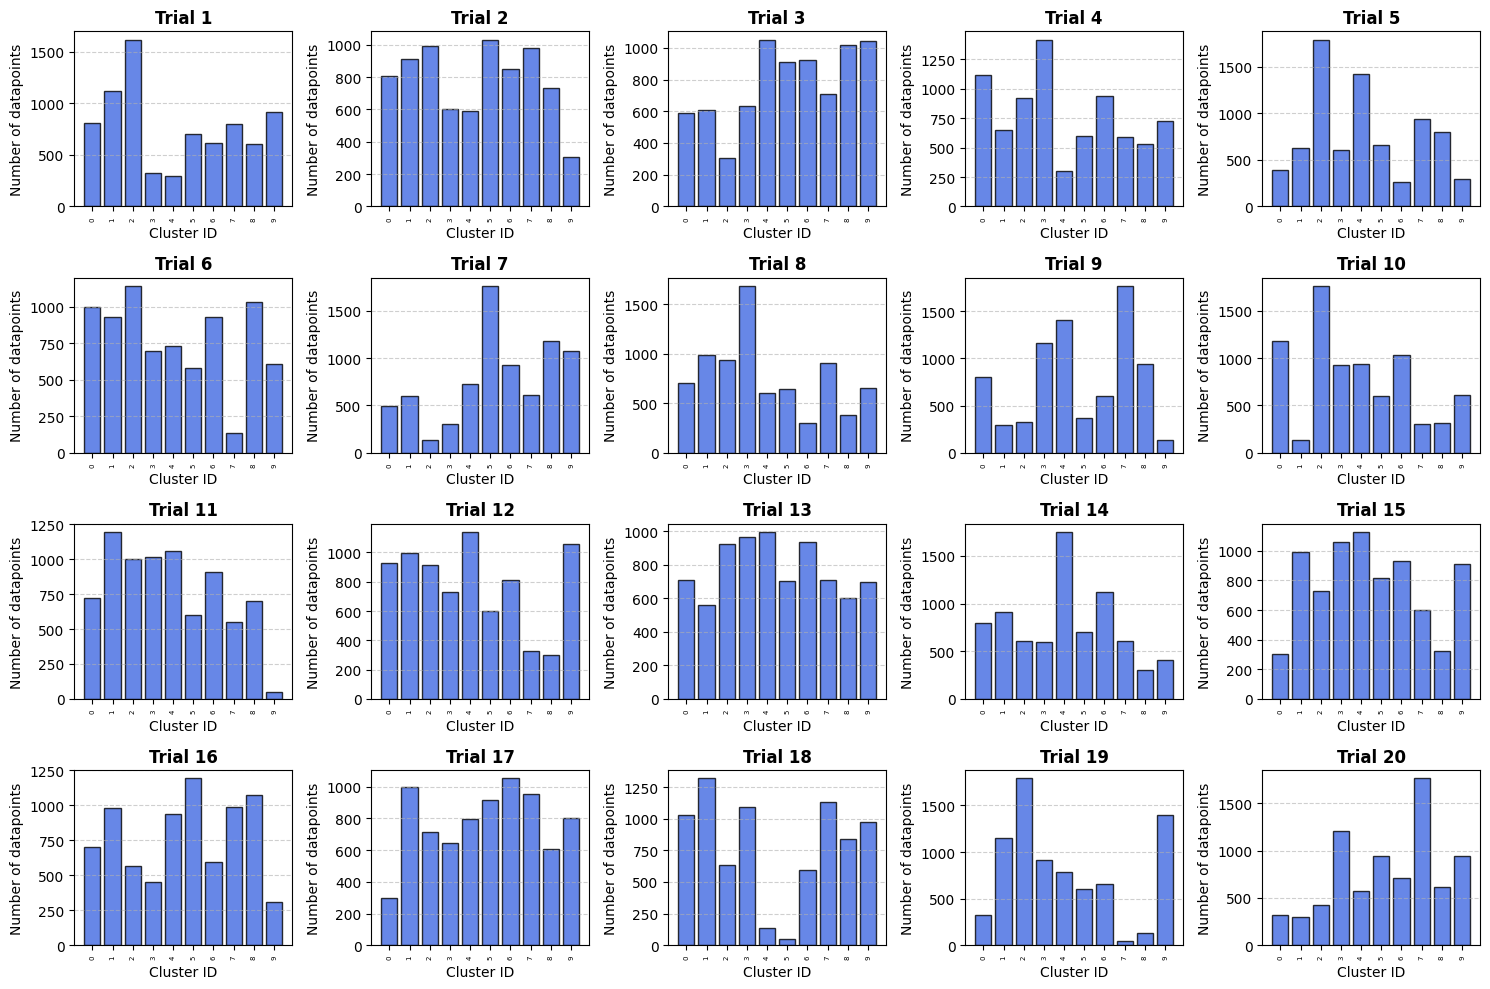


k = 26
--------------------


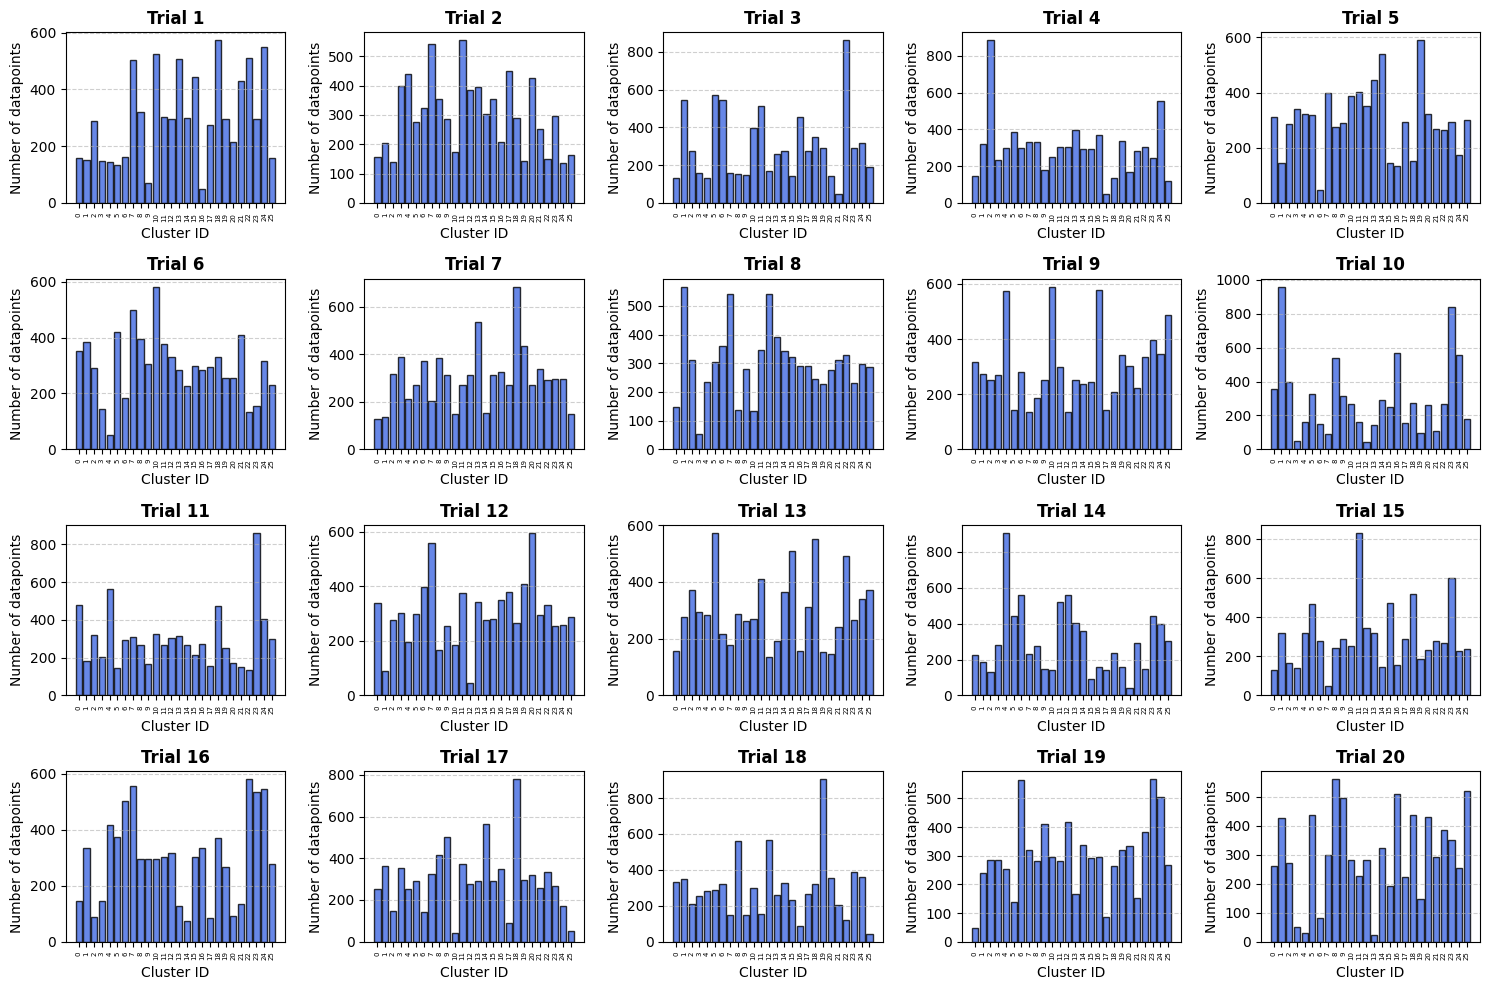


k = 50
--------------------


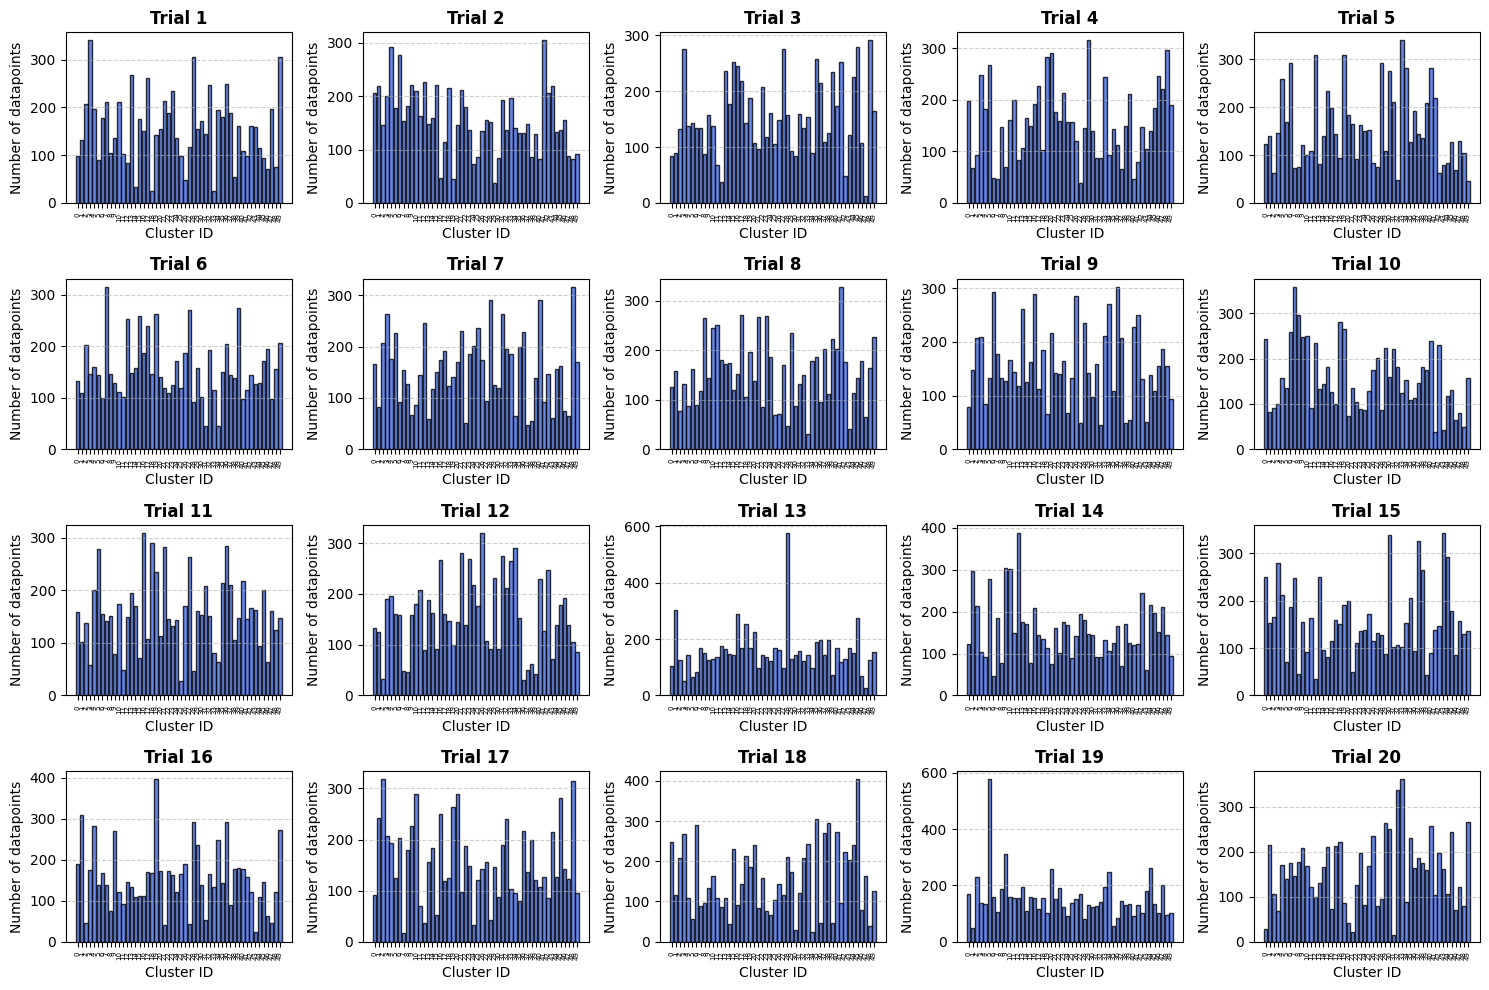

In [33]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(real_stats[k]['kmeans']['bincounts'], f'cl_sz_distr_real_km_k{k}')
    if i < len(real_k_values) - 1: print()

### KMeans++ executions

In [34]:
for k in real_k_values:
    real_stats[k]['kmeanspp'] = run_trials(kmeans_plus_plus, k, X_real, trials)

#### Stats

In [35]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(real_stats[k]['kmeanspp']['times']):.4f} s")
    print(f"Average inertia: {np.mean(real_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(real_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(real_stats[k]['kmeanspp']['inertias']):.4e}")
    if i < len(real_k_values) - 1: print()

k = 10
--------------------
Average execution time: 4.1669 s
Average inertia: 3.1749e+06
Inertia standard deviation: 3.5158e+04
Minimum inertia: 3.1352e+06

k = 26
--------------------
Average execution time: 12.7623 s
Average inertia: 2.6712e+06
Inertia standard deviation: 9.3169e+03
Minimum inertia: 2.6564e+06

k = 50
--------------------
Average execution time: 25.4543 s
Average inertia: 2.4404e+06
Inertia standard deviation: 8.8083e+03
Minimum inertia: 2.4255e+06


#### Cluster sizes distributions

k = 10
--------------------


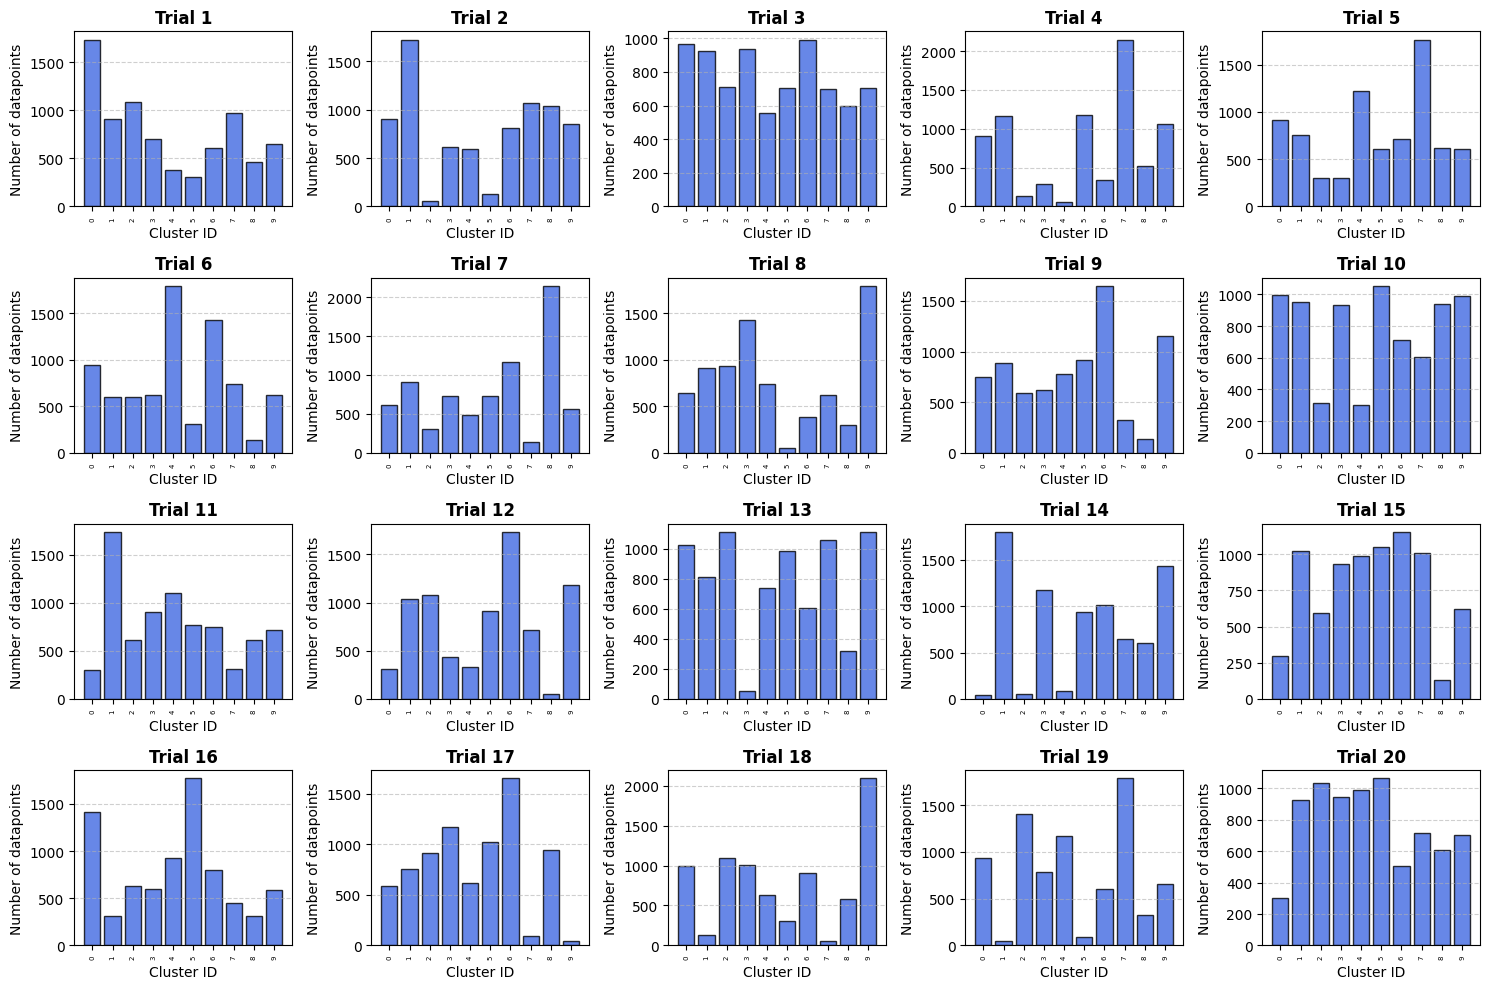


k = 26
--------------------


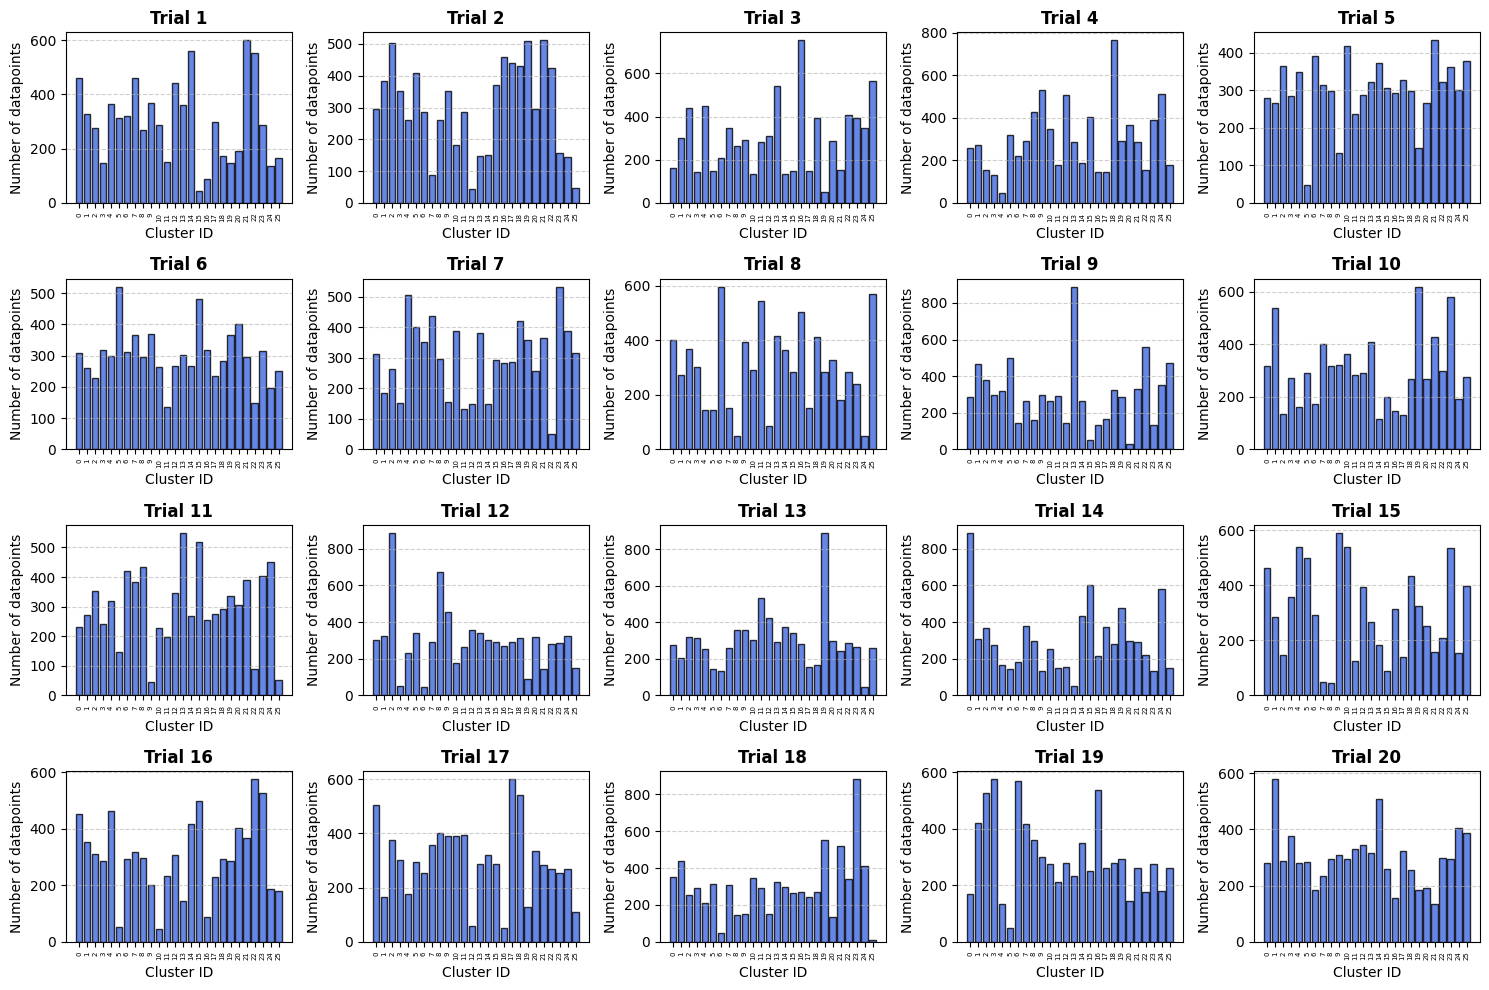


k = 50
--------------------


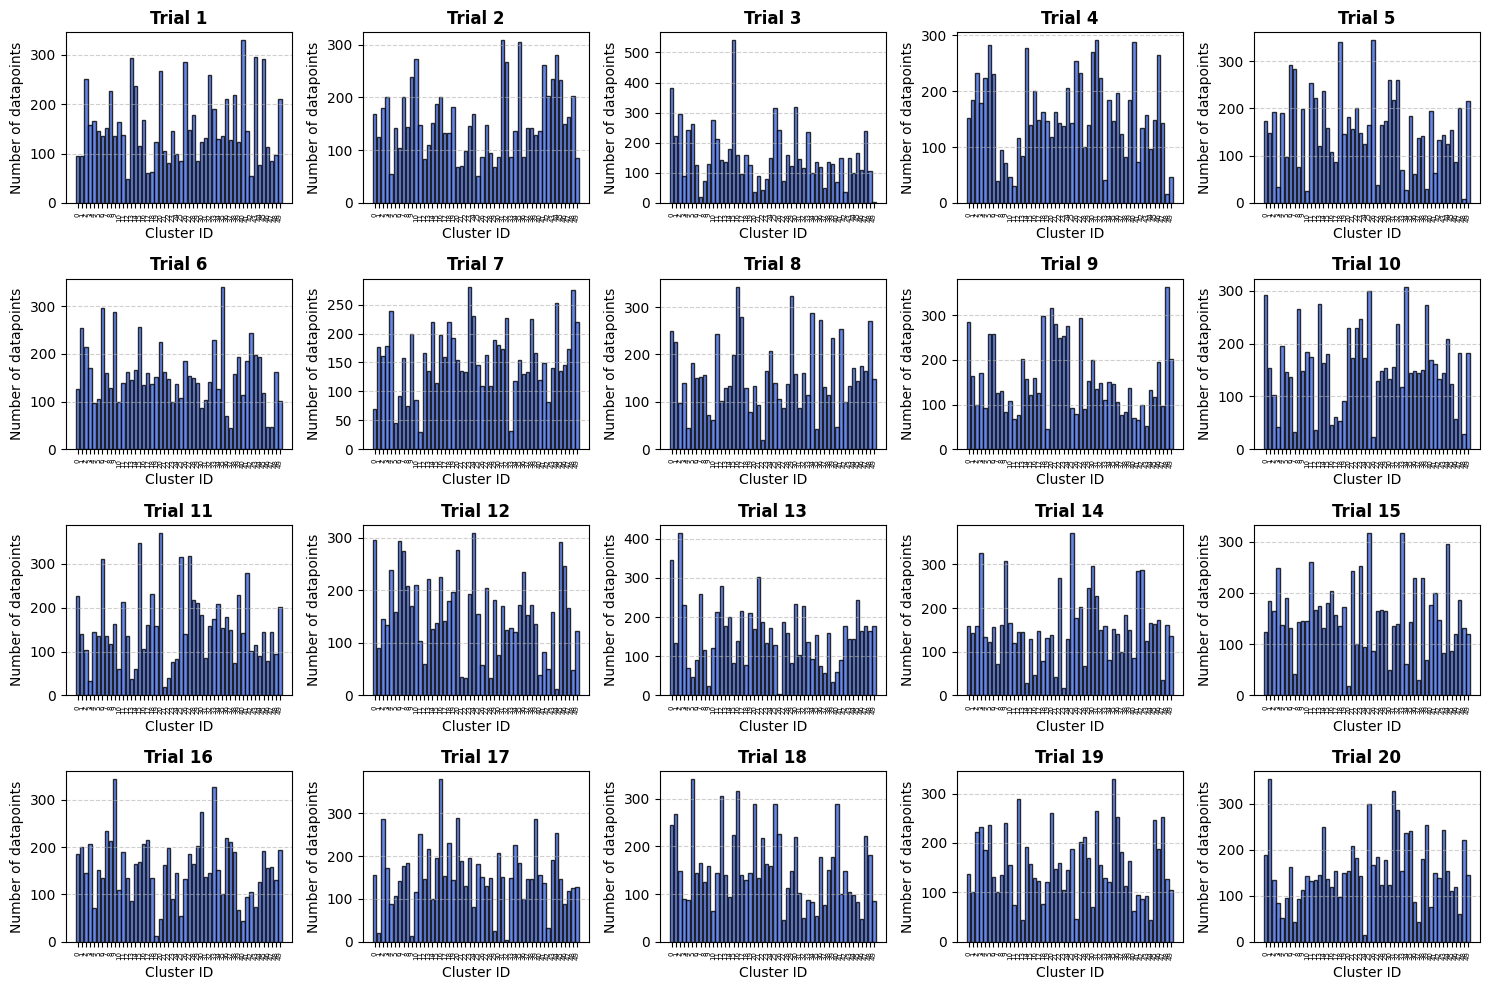

In [36]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(real_stats[k]['kmeanspp']['bincounts'], f'cl_sz_distr_real_kmpp_k{k}')
    if i < len(real_k_values) - 1: print()

### Improvement analysis

In [37]:
for i, (k, v) in enumerate(real_stats.items()):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time improvement: {100*(1- np.mean(real_stats[k]['kmeanspp']['times']) / np.mean(real_stats[k]['kmeans']['times']))}%")
    print(f"Average inertia improvement: {100*(1-np.mean(real_stats[k]['kmeanspp']['inertias']) / np.mean(real_stats[k]['kmeans']['inertias']))}%")
    print(f"Inertia standard deviation improvement: {100*(1-np.std(real_stats[k]['kmeanspp']['inertias']) / np.std(real_stats[k]['kmeans']['inertias']))}%")
    print(f"Minimum inertia improvement: {100*(1-np.min(real_stats[k]['kmeanspp']['inertias']) / np.min(real_stats[k]['kmeans']['inertias']))}%")
    if i < len(real_stats.items()) - 1: print()

k = 10
--------------------
Average execution time improvement: 3.339311777021481%
Average inertia improvement: -0.6959957538847261%
Inertia standard deviation improvement: -191.4590357705782%
Minimum inertia improvement: 0.0051224400689164895%

k = 26
--------------------
Average execution time improvement: 2.056276620867792%
Average inertia improvement: 0.5253180583008388%
Inertia standard deviation improvement: 62.320952890165636%
Minimum inertia improvement: -0.5567324575302512%

k = 50
--------------------
Average execution time improvement: -14.111996348997934%
Average inertia improvement: 0.2794013735078593%
Inertia standard deviation improvement: 3.101138341580645%
Minimum inertia improvement: 0.2063192634629285%


### Stability analysis

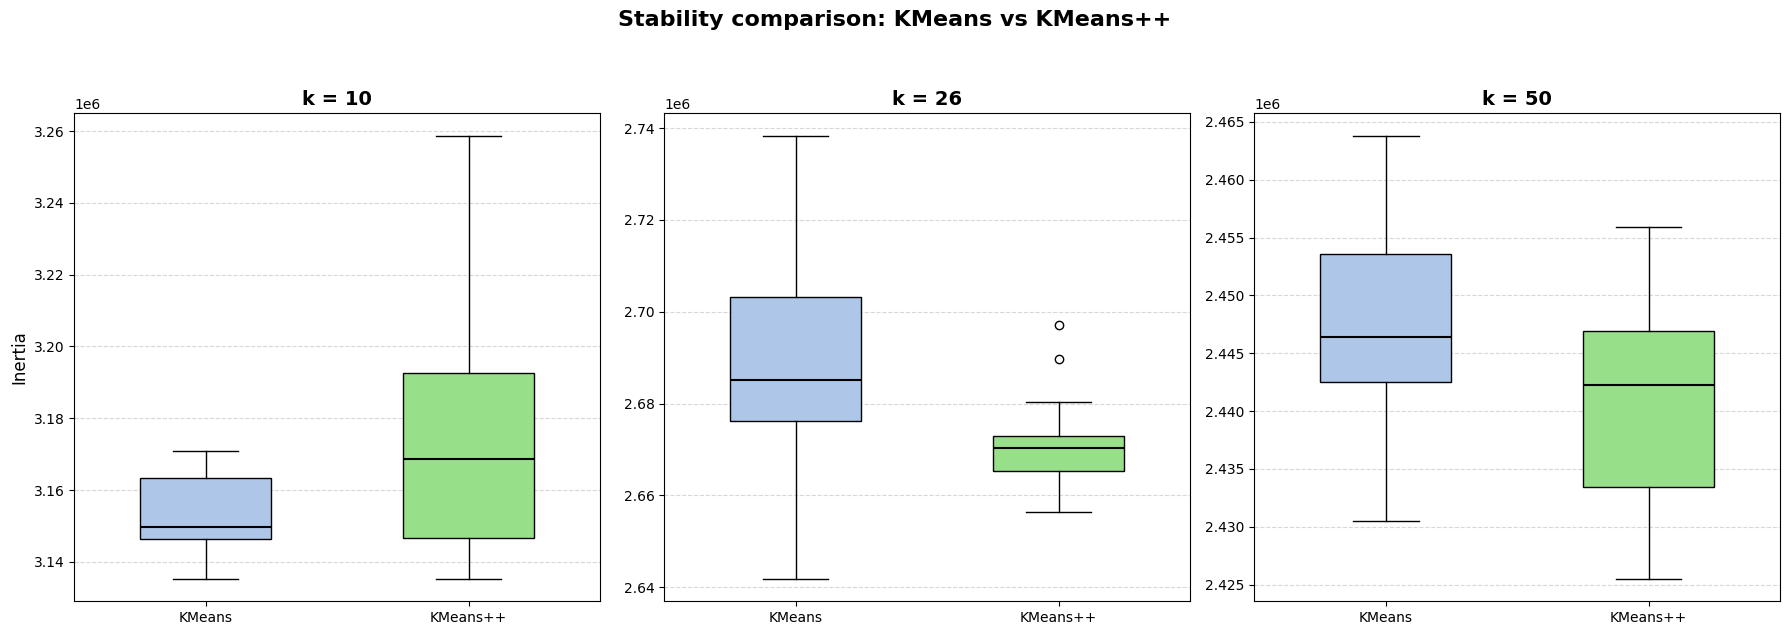

In [38]:
show_stability_graphs(real_stats, 'stab_real')